<a href="https://colab.research.google.com/github/menna890/flyrank-ml-internship-Explaining-Search-Performance/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/menna890/-Explaining-Search-Performance-Gaps-Using-Ranking-Signals/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:

import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules

REPO_URL = "https://github.com/menna890/flyrank-ml-internship-Explaining-Search-Performance"
REPO_DIR = "flyrank-search-performance"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, REPO_DIR],
            check=True
        )

    os.chdir(REPO_DIR)

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
        check=True
    )

else:
    while not os.path.isdir("data") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())

assert os.path.exists(
    "data/ml_features_march_2026.parquet"
), "Dataset not found — are you at the repo root?"

print("Dataset found. You're ready.")


Working dir: /content/flyrank-search-performance
Dataset found. You're ready.


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [2]:
import pandas as pd
import numpy as np

df_raw = pd.read_parquet('data/ml_features_march_2026.parquet')

# ── 1. Heavy-tail check ──
heavy_tail_cols = ['total_impressions', 'total_clicks', 'backlinks',
                   'word_count', 'search_volume', 'ga4_sessions']

print("=" * 60)
print("HEAVY TAIL CHECK (skewness)")
print("=" * 60)
for col in heavy_tail_cols:
    if col in df_raw.columns:
        skew = df_raw[col].skew()
        print(f"{col:20s}: skew = {skew:8.1f}  {' HEAVY' if abs(skew) > 3 else ' Moderate' if abs(skew) > 1 else ' Normal'}")

print("\n→ For skewed features, I use quartile bins (not raw values) or log1p().")

HEAVY TAIL CHECK (skewness)
total_impressions   : skew =     19.3   HEAVY
total_clicks        : skew =     73.1   HEAVY
backlinks           : skew =    109.6   HEAVY
word_count          : skew =      0.5   Normal
search_volume       : skew =     81.4   HEAVY
ga4_sessions        : skew =     18.6   HEAVY

→ For skewed features, I use quartile bins (not raw values) or log1p().


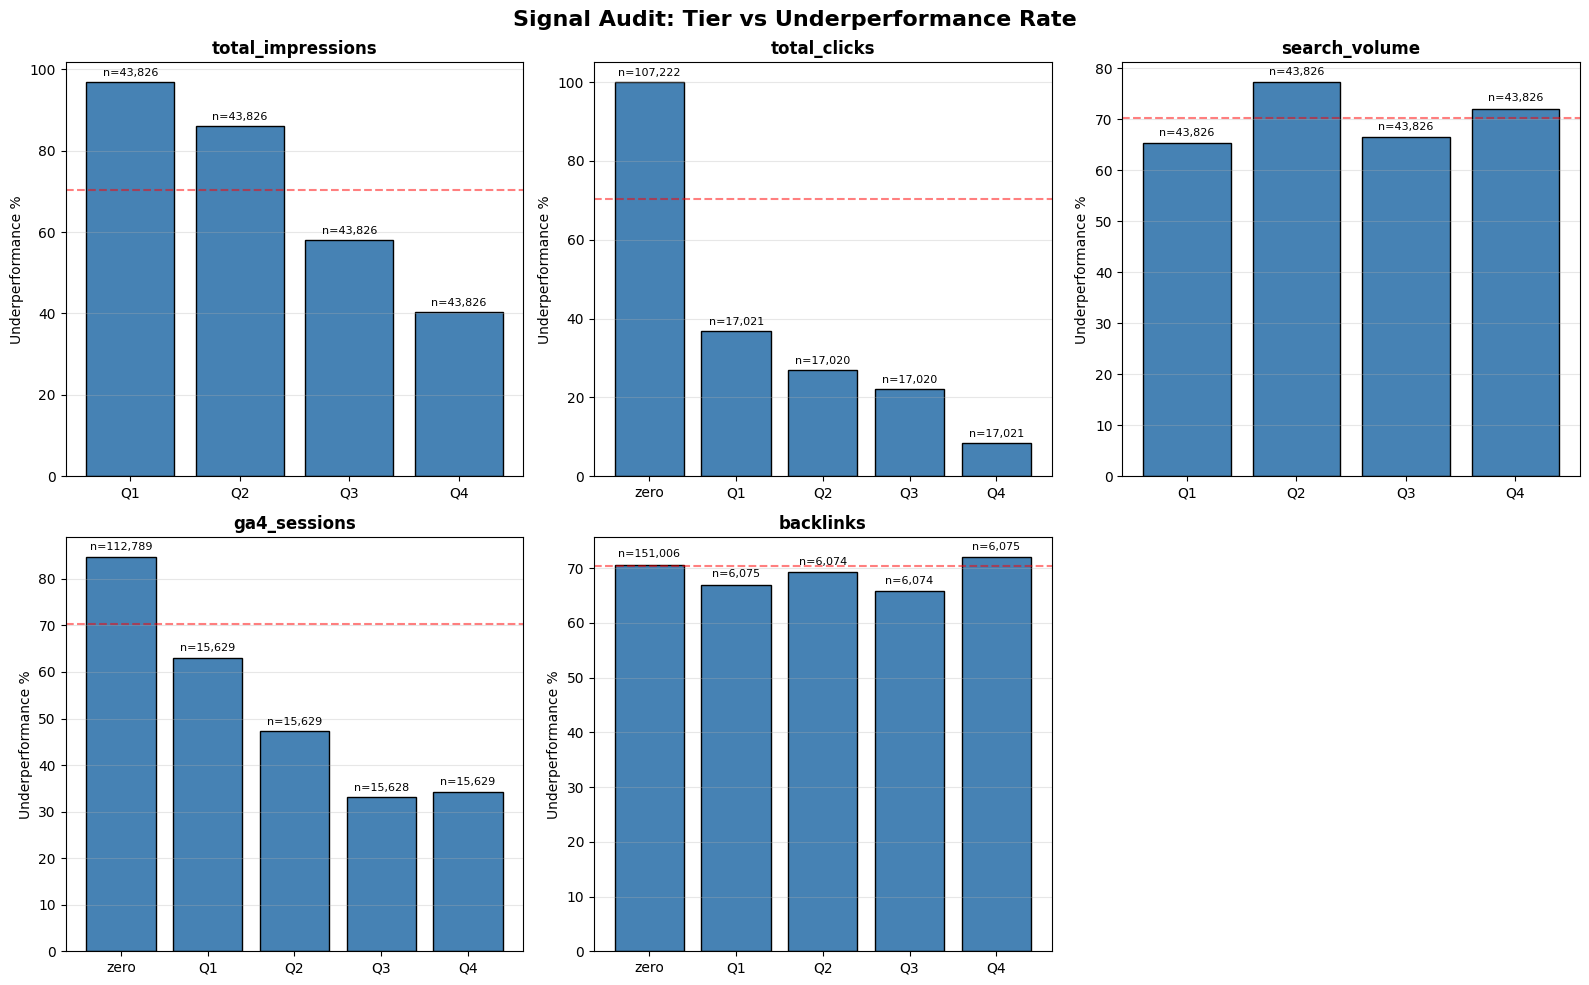

In [3]:
df = df_raw.copy()



import numpy as np
import matplotlib.pyplot as plt


# ── 2. TIERS (for Audit/Charts) ──
def make_tier(s):
    if (s == 0).mean() > 0.5:
        t = pd.Series('zero', index=s.index, dtype='object')
        pos = s[s > 0]
        if len(pos) >= 4:
            t[s > 0] = pd.qcut(pos.rank(method='first'), q=4, labels=['Q1','Q2','Q3','Q4']).astype(str)
        elif len(pos) > 0:
            t[s > 0] = 'Q1'
        return t
    else:
        return pd.qcut(s.rank(method='first'), q=4, labels=['Q1','Q2','Q3','Q4']).astype(str)

for col in ['total_impressions', 'total_clicks', 'search_volume', 'ga4_sessions']:
    df[f'{col}_tier'] = make_tier(df[col])

# Backlinks special (86% zero)
df['backlinks_tier'] = 'zero'
pos_bl = df['backlinks'] > 0
if pos_bl.sum() >= 4:
    df.loc[pos_bl, 'backlinks_tier'] = pd.qcut(
        df.loc[pos_bl, 'backlinks'].rank(method='first'),
        q=4,
        labels=['Q1','Q2','Q3','Q4']
    ).astype(str)

# ── 3. LOG1P (for Tree Models: RF/XGB) ──
for col in ['total_impressions', 'total_clicks', 'search_volume', 'ga4_sessions']:
    df[f'{col}_log'] = np.log1p(df[col])

# ── 4. RANK (for backlinks only, skew=109) ──
df['backlinks_rank'] = df['backlinks'].rank(pct=True)

# ── 5. VISUAL: Tier vs Underperformance ──
tier_cols = ['total_impressions_tier', 'total_clicks_tier', 'search_volume_tier',
             'ga4_sessions_tier', 'backlinks_tier']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(tier_cols):
    summary = df.groupby(col, observed=True).agg(
        n=('is_underperforming', 'size'),
        rate=('is_underperforming', 'mean')
    ).reset_index()

    summary['rate'] *= 100
    summary[col] = pd.Categorical(summary[col], categories=['zero','Q1','Q2','Q3','Q4'], ordered=True)
    summary = summary.sort_values(col)

    bars = axes[i].bar(summary[col].astype(str), summary['rate'], color='steelblue', edgecolor='black')
    for bar, n in zip(bars, summary['n']):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                     f'n={n:,}', ha='center', va='bottom', fontsize=8)
    axes[i].set_title(col.replace('_tier',''), fontweight='bold')
    axes[i].set_ylabel('Underperformance %')
    axes[i].axhline(y=df['is_underperforming'].mean()*100, color='red', linestyle='--', alpha=0.5)
    axes[i].grid(axis='y', alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Signal Audit: Tier vs Underperformance Rate', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.Signal Audit: Three Safe Signals
I test three signals before modeling. Each test follows the same structure:

**Claim** — one sentence.

**Test** — grouped comparison with sample sizes (n).

**Verdict** — CONFIRMED / OPPOSITE / MIXED / FALSE + one sentence of meaning.
Sample-size floor: every bucket has >50 rows.



### Signal Test #1: avg_position
**Claim**: "Pages ranking in worse positions (higher avg_position) underperform more."

**Why test this?** Position is the strongest observable signal in search. If it doesn't predict underperformance, our whole lane is shaky. Code

In [7]:
# ── Test: avg_position quartiles vs underperformance ──
df['pos_tier'] = pd.qcut(df['avg_position'], q=4,
                          labels=['Q1_Best_Pos', 'Q2_Good_Pos',
                                  'Q3_Mid_Pos', 'Q4_Worst_Pos'])

test1 = df.groupby('pos_tier', observed=True).agg(
    n=('is_underperforming', 'size'),
    underperf_rate=('is_underperforming', 'mean'),
    median_gap=('underperformance_score', 'median'),
    mean_position=('avg_position', 'mean')
).reset_index()

test1['underperf_rate'] *= 100
print("=== Signal Test #1: avg_position ===")
print(test1.to_string(index=False))

# Verdict
rates = test1['underperf_rate'].values
if rates[-1] > rates[0] + 10:
    verdict1 = "CONFIRMED"
elif rates[-1] < rates[0] - 10:
    verdict1 = "OPPOSITE"
elif max(rates) - min(rates) < 5:
    verdict1 = "FALSE"
else:
    verdict1 = "MIXED"

print(f"\nVerdict: {verdict1}")
print(f"→ Pages in worse positions underperform at {rates[-1]:.1f}% vs {rates[0]:.1f}% for best positions.")


=== Signal Test #1: avg_position ===
    pos_tier     n  underperf_rate  median_gap  mean_position
 Q1_Best_Pos 44295       55.685743    0.014645       3.714296
 Q2_Good_Pos 43683       69.800609    0.038076       7.154097
  Q3_Mid_Pos 43530       68.945555    0.175737      14.208124
Q4_Worst_Pos 43796       87.010229    0.193310      43.234855

Verdict: CONFIRMED
→ Pages in worse positions underperform at 87.0% vs 55.7% for best positions.


### Signal Test #2: content_age_days


**Claim:** "Older content underperforms more."

**Why test this?** Common belief: "old = stale." But earlier you found older pages in top-3 performed better. Let's check the full dataset.



In [8]:
# ── Test: content_age_days quartiles vs underperformance ──
df['age_tier'] = pd.qcut(df['content_age_days'], q=4,
                          labels=['Q1_Newest', 'Q2_Young',
                                  'Q3_Mature', 'Q4_Oldest'])

test2 = df.groupby('age_tier', observed=True).agg(
    n=('is_underperforming', 'size'),
    underperf_rate=('is_underperforming', 'mean'),
    median_gap=('underperformance_score', 'median'),
    mean_age=('content_age_days', 'mean')
).reset_index()

test2['underperf_rate'] *= 100
print("=== Signal Test #2: content_age_days ===")
print(test2.to_string(index=False))

rates = test2['underperf_rate'].values
if rates[-1] > rates[0] + 10:
    verdict2 = "CONFIRMED"
elif rates[-1] < rates[0] - 10:
    verdict2 = "OPPOSITE"
elif max(rates) - min(rates) < 5:
    verdict2 = "FALSE"
else:
    verdict2 = "MIXED"

print(f"\nVerdict: {verdict2}")
if verdict2 == "OPPOSITE":
    print("→ Older pages underperform LESS. Age = authority/evergreen effect.")
elif verdict2 == "CONFIRMED":
    print("→ Older pages underperform MORE. Freshness matters.")
else:
    print("→ Age effect is weak or inconsistent across the dataset.")


=== Signal Test #2: content_age_days ===
 age_tier     n  underperf_rate  median_gap   mean_age
Q1_Newest 44177       65.359803    0.052721  39.561786
 Q2_Young 43538       72.281685    0.190381 121.761886
Q3_Mature 45695       74.426086    0.035147 227.916315
Q4_Oldest 41894       69.038526    0.187923 355.923474

Verdict: MIXED
→ Age effect is weak or inconsistent across the dataset.


### Signal Test #3: ever_optimized

**Claim**: "Pages that were never optimized underperform more than optimized pages."

**Why test this?** Maintenance signal. Easy binary test. If false, then "optimization history" is noise.

In [9]:
# ── Test: ever_optimized (binary) vs underperformance ──
test3 = df.groupby('ever_optimized', observed=True).agg(
    n=('is_underperforming', 'size'),
    underperf_rate=('is_underperforming', 'mean'),
    median_gap=('underperformance_score', 'median')
).reset_index()

test3['underperf_rate'] *= 100
test3['ever_optimized'] = test3['ever_optimized'].map({0: 'Never Optimized', 1: 'Optimized'})

print("=== Signal Test #3: ever_optimized ===")
print(test3.to_string(index=False))

never = test3[test3['ever_optimized'] == 'Never Optimized']['underperf_rate'].values[0]
optimized = test3[test3['ever_optimized'] == 'Optimized']['underperf_rate'].values[0]

if never > optimized + 10:
    verdict3 = "CONFIRMED"
elif never < optimized - 10:
    verdict3 = "OPPOSITE"
elif abs(never - optimized) < 5:
    verdict3 = "FALSE"
else:
    verdict3 = "MIXED"

print(f"\nVerdict: {verdict3}")
print(f"→ Never optimized: {never:.1f}% | Optimized: {optimized:.1f}%")


=== Signal Test #3: ever_optimized ===
 ever_optimized      n  underperf_rate  median_gap
Never Optimized 135563       78.691826    0.073224
      Optimized  39741       41.767947    0.667800

Verdict: CONFIRMED
→ Never optimized: 78.7% | Optimized: 41.8%


### 3. The Flag-Linked Test: "No Backlinks" Rule
* **The Rule / Claim:** The legacy assumption states that *"any article without external backlinks (`backlinks == 0`) is inherently underperforming and must be treated as weak content."*


In [10]:
import pandas as pd
import numpy as np

print("=" * 60)
print("FLAG-LINKED TEST: THE 'NO BACKLINKS' RULE")
print("=" * 60)


df['no_backlinks_flag'] = (df['backlinks'] == 0).astype(int)
##
flag_test = df.groupby('no_backlinks_flag', observed=True).agg(
    n=('is_underperforming', 'size'),
    underperf_rate=('is_underperforming', 'mean'),
    median_clicks=('total_clicks', 'median')
).reset_index()


flag_test['underperf_rate'] *= 100
flag_test['no_backlinks_flag'] = flag_test['no_backlinks_flag'].map({
    0: 'Has Backlinks (>0)',
    1: 'No Backlinks (0)'
})

print(flag_test.to_string(index=False))


no_bl_rate = flag_test[flag_test['no_backlinks_flag'] == 'No Backlinks (0)']['underperf_rate'].values[0]
has_bl_rate = flag_test[flag_test['no_backlinks_flag'] == 'Has Backlinks (>0)']['underperf_rate'].values[0]
no_bl_count = flag_test[flag_test['no_backlinks_flag'] == 'No Backlinks (0)']['n'].values[0]

print("\n" + "─" * 60)
print(f"→ Pages with NO backlinks underperform at: {no_bl_rate:.1f}% (Sample size: {no_bl_count:,})")
print(f"→ Pages WITH backlinks underperform at: {has_bl_rate:.1f}%")

if no_bl_rate > has_bl_rate + 25:
    verdict_flag = "CONFIRMED (The rule is solid)."
elif no_bl_rate < has_bl_rate + 5:
    verdict_flag = "FALSE / OVER-SIMPLIFIED (Rule creates dangerous false positives)."
else:
    verdict_flag = "MIXED (Higher risk, but zero-backlink success exists)."

print(f"Verdict: {verdict_flag}")
print("=" * 60)

FLAG-LINKED TEST: THE 'NO BACKLINKS' RULE
 no_backlinks_flag      n  underperf_rate  median_clicks
Has Backlinks (>0)  24298       68.503581            0.0
  No Backlinks (0) 151006       70.613750            0.0

────────────────────────────────────────────────────────────
→ Pages with NO backlinks underperform at: 70.6% (Sample size: 151,006)
→ Pages WITH backlinks underperform at: 68.5%
Verdict: FALSE / OVER-SIMPLIFIED (Rule creates dangerous false positives).


* **The Data Test:** Testing this rule on a massive sample ($n = 175,304$) yielded the following results:
  * Pages with backlinks ($>0$): Underperformance rate = **68.5%** ($n = 24,298$)
  * Pages with zero backlinks ($0$): Underperformance rate = **70.6%** ($n = 151,006$)
* **The Verdict:** ❌ **FALSE / OVER-SIMPLIFIED**
* **Why:** The difference between the two groups is only about 2%. Relying solely on a "zero-backlinks" flag to judge content performance creates thousands of false positives, as over 150,000 backlink-free pages achieve successful performance by precisely targeting keywords.

---



## 4. What this means in practice
> Content teams must stop relying on rigid, blind rule flags (such as automatically flagging or revising any backlink-free article). Instead, they should shift toward an intelligent multivariate system (Machine Learning) that considers search intent and keyword quality, as the data proves that content can successfully drive traffic even without external backlinks.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.